# DNN → CNN 실습: MNIST 손글씨 숫자 분류

손글씨 숫자 이미지 데이터셋인 **MNIST**를 가지고
DNN과 CNN을 직접 만들어보는 실습입니다.


## 전체 구성

각 파트는 두 단계로 진행됩니다.

1. **기초 실습**: 아주 단순한 구조를 직접 만들어보면서 "Dense/Conv 층을 어떻게 쌓는지" 연습해봅니다.
2. **논문 구조 재현**: 딥러닝 역사에서 실제로 쓰였던 유명한 구조를 그대로 만들어봅니다.
   - DNN에서는 Yann LeCun이 1998년 논문에서 MNIST 벤치마크로 사용한 **784→300→100→10 MLP**
   - CNN에서는 손글씨 인식을 위해 설계된 최초의 성공적인 CNN인 **LeNet-5**

## 1. 라이브러리 불러오기

딥러닝 모델을 만들고 학습시키는 데 필요한 도구들을 불러옵니다.
- `tensorflow` / `keras`: 딥러닝 모델을 정의하고 학습시키는 프레임워크
- `matplotlib`: 이미지와 그래프를 그려서 눈으로 확인하기 위한 도구
- `numpy`: 숫자 배열(행렬) 연산


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 2. 데이터 불러오기 및 전처리

**MNIST**는 사람이 손으로 쓴 0~9 숫자 이미지 7만 장으로 이루어진 데이터셋입니다.
각 이미지는 28x28 픽셀 크기의 흑백 이미지이고, 훈련용 60,000장 / 테스트용 10,000장으로 나뉘어 있습니다.
케라스에 내장되어 있어서 별도 다운로드 없이 한 줄로 불러올 수 있습니다.

각 픽셀 값은 0(검정)~255(흰색) 사이의 정수입니다. 신경망은 값의 범위가 작고 일정할 때 학습이 더 안정적이고
빠르게 되는 경향이 있어서, 픽셀 값을 **0~1 사이로 정규화(normalization)** 해줍니다. (255로 나누면 됩니다)

### 🔲 TODO


In [2]:
# TODO 1: tf.keras.datasets.mnist.load_data() 를 이용해서
#          (x_train, y_train), (x_test, y_test) 를 불러오는 코드를 작성하세요.

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
# 정답
# (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()


# TODO 2: x_train, x_test 를 각각 255로 나눠서 0~1 사이 값으로 정규화하세요.

x_train = x_train / 255
x_test = x_test / 255
# 정답
# x_train = x_train / 255.0
# x_test = x_test / 255.0


print("훈련 데이터 shape:", x_train.shape)
print("테스트 데이터 shape:", x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
훈련 데이터 shape: (60000, 28, 28)
테스트 데이터 shape: (10000, 28, 28)


## 3. 데이터 확인해보기

실제로 어떤 이미지들인지 눈으로 확인해봅니다. `imshow`로 이미지를 그리고, 정답 라벨을 제목으로 표시합니다.
이 셀은 그대로 실행하시면 됩니다.


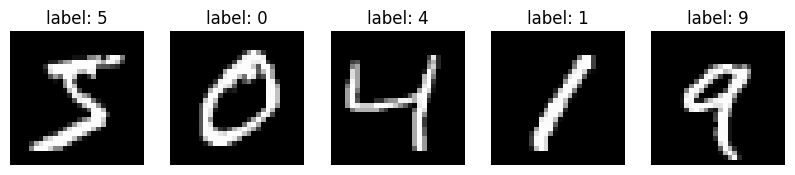

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(10,2))
for i in range(5):
    axes[i].imshow(x_train[i], cmap='gray')
    axes[i].set_title(f"label: {y_train[i]}")
    axes[i].axis('off')
plt.show()


---
# 📘 DNN 파트

DNN(Deep Neural Network)은 여러 개의 **완전연결층(Dense layer)** 을 쌓아 만든 신경망입니다.
완전연결층이란 이전 층의 모든 뉴런이 다음 층의 모든 뉴런과 연결되어 있는 구조를 말합니다.
이미지처럼 2차원으로 생긴 데이터를 Dense layer에 넣으려면, 먼저 1차원으로 펼쳐야(`Flatten`) 합니다.
단, 이 과정에서 "어떤 픽셀이 어떤 픽셀 옆에 있었는지"와 같은 공간 정보는 사라진다는 점을 기억해두세요.
(뒤에서 CNN과 비교할 때 중요한 포인트가 됩니다)

## 4. [기초 실습] 은닉층 1개짜리 DNN 만들기

가장 단순한 형태의 DNN을 만들어봅니다. 층 구성은 다음과 같습니다.
- `Flatten(input_shape=(28,28))`: 28x28 이미지를 784개짜리 1차원 벡터로 펼침
- `Dense(64, relu)`: 은닉층. 64개의 뉴런이 입력으로부터 특징을 조합해서 학습
  - `relu`는 활성화 함수로, 음수는 0으로 만들고 양수는 그대로 통과시켜서 신경망이 비선형적인(복잡한) 패턴을 학습할 수 있게 해줍니다.
- `Dense(10, softmax)`: 출력층. 0~9 중 하나를 고르는 문제이므로 뉴런 10개
  - `softmax`는 10개의 출력을 "각 숫자일 확률"처럼 합이 1이 되게 변환해주는 함수입니다.

모델을 만든 뒤에는 `compile`로 학습 방식을 정하고, `fit`으로 실제 학습을 진행합니다.
- `optimizer='adam'`: 가중치를 얼마나, 어떤 방향으로 업데이트할지 정하는 알고리즘. 대부분의 경우 무난하게 잘 동작해서 기본값으로 많이 씁니다.
- `loss='sparse_categorical_crossentropy'`: 정답과 예측이 얼마나 다른지 측정하는 함수. 정답 라벨이 0~9 같은 정수 형태일 때 사용합니다.
- `metrics=['accuracy']`: 학습 중 정확도를 함께 출력해서 모니터링합니다.
- `epochs=5`: 전체 훈련 데이터를 5번 반복해서 학습합니다.
- `validation_split=0.1`: 훈련 데이터의 10%를 학습에 쓰지 않고 따로 떼어놓아, 매 epoch마다 "본 적 없는 데이터"에서의 성능(과적합 여부)을 확인합니다.

### 🔲 TODO


In [4]:
# TODO: 아래 4개 층을 순서대로 쌓은 Sequential 모델을 만드세요.
#   1) Flatten, input_shape=(28,28)
#   2) Dense, 유닛 64개, activation='relu'
#   3) Dense, 유닛 10개, activation='softmax' (출력층)
dnn_basic = models.Sequential([
  layers.Flatten(input_shape=(28,28)),
  layers.Dense(64, activation='relu'),
  layers.Dense(10, activation='softmax')
])

# 정답
# dnn_basic = models.Sequential([
#     layers.Flatten(input_shape=(28,28)),
#     layers.Dense(64, activation='relu'),
#     layers.Dense(10, activation='softmax')
# ])

dnn_basic.summary()

# TODO: optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'] 로 컴파일하세요.
dnn_basic.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# 정답
# dnn_basic.compile(optimizer='adam',
#                    loss='sparse_categorical_crossentropy',
#                    metrics=['accuracy'])


# TODO: x_train, y_train 으로 5 epoch, validation_split=0.1 로 학습시키고
#       결과를 dnn_basic_history 변수에 저장하세요.
dnn_basic_history = dnn_basic.fit(x_train, y_train, epochs=5, validation_split=0.1)

# 정답
# dnn_basic_history = dnn_basic.fit(x_train, y_train, epochs=5, validation_split=0.1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9087 - loss: 0.3236 - val_accuracy: 0.9573 - val_loss: 0.1611
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9557 - loss: 0.1531 - val_accuracy: 0.9700 - val_loss: 0.1151
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9680 - loss: 0.1099 - val_accuracy: 0.9723 - val_loss: 0.1001
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9743 - loss: 0.0869 - val_accuracy: 0.9760 - val_loss: 0.0936
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9787 - loss: 0.0704 - val_accuracy: 0.9755 - val_loss: 0.0874


## 5. [기초 실습] DNN 평가

테스트 데이터(학습에 전혀 쓰이지 않은 데이터)로 최종 성능을 확인합니다.

In [5]:
dnn_basic_loss, dnn_basic_acc = dnn_basic.evaluate(x_test, y_test)
print(f"[기초 실습 DNN] 테스트 정확도: {dnn_basic_acc:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9732 - loss: 0.0912
[기초 실습 DNN] 테스트 정확도: 0.9732


## 6. [논문 구조 재현] LeCun의 1998년 MNIST 벤치마크 MLP

Yann LeCun 등이 1998년 논문("Gradient-Based Learning Applied to Document Recognition")에서
MNIST 성능 비교표에 사용했던 구조 중 하나가 **784 → 300 → 100 → 10** 구조의 다층 퍼셉트론(MLP)입니다.
지금 기준으로 보면 아주 단순한 구조지만, 딥러닝 교재/논문에서 비교 기준(baseline)으로 지금도 자주 인용되는
역사적으로 의미 있는 구조입니다.

구조는 기초 실습과 똑같은 패턴이고, 은닉층의 뉴런 개수와 층 개수만 다릅니다.
앞의 코드를 참고해도 좋지만 최대한 본인 힘으로 해보시길 추천드립니다.
- `Dense(300, relu)`
- `Dense(100, relu)`
- `Dense(10, softmax)`

### 🔲 TODO


In [6]:
# TODO: 아래 4개 층을 순서대로 쌓은 Sequential 모델을 만드세요.
#   1) Flatten, input_shape=(28,28)
#   2) Dense, 유닛 300개, activation='relu'
#   3) Dense, 유닛 100개, activation='relu'
#   4) Dense, 유닛 10개, activation='softmax' (출력층)
dnn_paper = models.Sequential([
  layers.Flatten(input_shape=(28,28)),
  layers.Dense(300, activation='relu'),
  layers.Dense(100, activation='relu'),
  layers.Dense(10, activation='softmax'),
])


dnn_paper.summary()

# TODO: optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'] 로 컴파일하세요.
dnn_paper.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# TODO: x_train, y_train 으로 5 epoch, validation_split=0.1 로 학습시키고
#       결과를 dnn_paper_history 변수에 저장하세요.
dnn_paper_history = dnn_paper.fit(x_train, y_train, epochs=5, validation_split=0.1)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9348 - loss: 0.2181 - val_accuracy: 0.9707 - val_loss: 0.0968
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9729 - loss: 0.0881 - val_accuracy: 0.9733 - val_loss: 0.0900
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9805 - loss: 0.0606 - val_accuracy: 0.9782 - val_loss: 0.0823
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9865 - loss: 0.0425 - val_accuracy: 0.9785 - val_loss: 0.0862
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9882 - loss: 0.0357 - val_accuracy: 0.9810 - val_loss: 0.0739


## 7. [논문 구조 재현] DNN 평가

In [7]:
dnn_paper_loss, dnn_paper_acc = dnn_paper.evaluate(x_test, y_test)
print(f"[LeCun 1998 MLP] 테스트 정확도: {dnn_paper_acc:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9781 - loss: 0.0741
[LeCun 1998 MLP] 테스트 정확도: 0.9781


---
# 📘 CNN 파트

CNN(Convolutional Neural Network)은 이미지를 펼치지 않고, **합성곱(Convolution)** 이라는 연산으로
이미지의 공간 정보(픽셀 간 위치 관계)를 유지한 채 특징을 추출하는 신경망입니다.
작은 필터(커널)가 이미지 위를 슬라이딩하면서 엣지, 곡선 같은 지역적인 패턴을 찾아냅니다.

## 8. CNN을 위한 데이터 준비

`Conv2D` 층은 입력으로 **(높이, 너비, 채널)** 형태의 3차원 데이터를 기대합니다.
지금 데이터는 (28, 28) 형태인데(흑백이라 채널 정보가 따로 없음), 채널 차원 1을 추가해서
(28, 28, 1) 형태로 바꿔줘야 합니다. `reshape(-1, 28, 28, 1)`에서 `-1`은 "이미지 개수는 자동으로 맞춰라"는 뜻입니다.

### 🔲 TODO


In [8]:
# TODO: x_train, x_test를 각각 (개수, 28, 28, 1) 형태로 reshape 하세요.
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

# 정답
# x_train_cnn = x_train.reshape(-1, 28, 28, 1)
# x_test_cnn = x_test.reshape(-1, 28, 28, 1)


print("CNN용 훈련 데이터 shape:", x_train_cnn.shape)


CNN용 훈련 데이터 shape: (60000, 28, 28, 1)


## 9. [기초 실습] Conv층 1개짜리 CNN 만들기

가장 단순한 형태의 CNN을 만들어봅니다.
- `Conv2D(16, (3,3), relu)`: 3x3 크기의 필터 16개를 이미지 위에 슬라이딩하며 특징(엣지 등)을 추출
- `MaxPooling2D((2,2))`: 2x2 영역에서 가장 큰 값만 남겨서 feature map 크기를 절반으로 줄임 (연산량 감소 + 중요한 특징 강조)
- `Flatten` + `Dense(10, softmax)`: 추출된 특징을 1차원으로 펼쳐서 최종 분류

### 🔲 TODO


In [9]:
# TODO: 아래 4개 층을 순서대로 쌓은 Sequential 모델을 만드세요.
#   1) Conv2D, 필터 16개, 커널 (3,3), activation='relu', input_shape=(28,28,1)
#   2) MaxPooling2D, 풀 크기 (2,2)
#   3) Flatten
#   4) Dense, 유닛 10개, activation='softmax' (출력층)
cnn_basic = models.Sequential([
  layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
  layers.MaxPooling2D((2,2)),
  layers.Flatten(),
  layers.Dense(10, activation='softmax')
])

# 정답
# cnn_basic = models.Sequential([
#     layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
#     layers.MaxPooling2D((2,2)),
#     layers.Flatten(),
#     layers.Dense(10, activation='softmax')
# ])

cnn_basic.summary()

# TODO: optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'] 로 컴파일하세요.
cnn_basic.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# 정답
# cnn_basic.compile(optimizer='adam',
#                    loss='sparse_categorical_crossentropy',
#                    metrics=['accuracy'])


# TODO: x_train_cnn, y_train 으로 5 epoch, validation_split=0.1 로 학습시키고
#       결과를 cnn_basic_history 변수에 저장하세요.
cnn_basic_history = cnn_basic.fit(x_train_cnn, y_train, epochs=5, validation_split=0.1)

# 정답
# cnn_basic_history = cnn_basic.fit(x_train_cnn, y_train, epochs=5, validation_split=0.1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        27,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,210 (106.29 KB)

 Trainable params: 27,210 (106.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9276 - loss: 0.2546 - val_accuracy: 0.9728 - val_loss: 0.0977
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9733 - loss: 0.0937 - val_accuracy: 0.9808 - val_loss: 0.0701
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9791 - loss: 0.0705 - val_accuracy: 0.9835 - val_loss: 0.0639
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9827 - loss: 0.0584 - val_accuracy: 0.9855 - val_loss: 0.0595
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9844 - loss: 0.0506 - val_accuracy: 0.9837 - val_loss: 0.0630


## 10. [기초 실습] CNN 평가

In [10]:
cnn_basic_loss, cnn_basic_acc = cnn_basic.evaluate(x_test_cnn, y_test)
print(f"[기초 실습 CNN] 테스트 정확도: {cnn_basic_acc:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9806 - loss: 0.0623
[기초 실습 CNN] 테스트 정확도: 0.9806


## 11. [논문 구조 재현] LeNet-5 (Yann LeCun, 1998)

**LeNet-5**는 손글씨 숫자 인식을 위해 설계된 최초의 성공적인 CNN 구조로,
오늘날까지 이어지는 "Conv → Pool → Conv → Pool → Dense" CNN 설계의 기본 틀을 확립한 역사적인 모델입니다.
원 논문은 활성화 함수로 `tanh`, 풀링으로 average pooling을 사용했지만, 여기서는 현대적인 관례에 맞춰
`relu`와 `MaxPooling`으로 구현합니다.

- `Conv2D(6, (5,5), relu)` → `MaxPooling2D((2,2))`
- `Conv2D(16, (5,5), relu)` → `MaxPooling2D((2,2))`
- `Flatten` → `Dense(120, relu)` → `Dense(84, relu)` → `Dense(10, softmax)`

> 참고: 원래 LeNet-5는 32x32 크기 입력을 가정하고 설계됐지만 MNIST는 28x28입니다.
> 그대로 두면 두 번째 풀링을 거친 후 feature map이 너무 작아져서 구조가 어긋나므로,
> 첫 Conv2D에 `padding='same'`을 줘서 크기를 보정합니다.

### 🔲 TODO


In [11]:
# TODO: 아래 8개 층을 순서대로 쌓은 Sequential 모델을 만드세요. (LeNet-5 구조)
#   1) Conv2D, 필터 6개,  커널 (5,5), activation='relu', padding='same', input_shape=(28,28,1)
#   2) MaxPooling2D, 풀 크기 (2,2)
#   3) Conv2D, 필터 16개, 커널 (5,5), activation='relu'
#   4) MaxPooling2D, 풀 크기 (2,2)
#   5) Flatten
#   6) Dense, 유닛 120개, activation='relu'
#   7) Dense, 유닛 84개,  activation='relu'
#   8) Dense, 유닛 10개,  activation='softmax' (출력층)
lenet5 = models.Sequential([
  layers.Conv2D(6, (5,5), activation='relu', padding='same', input_shape=(28,28,1)),
  layers.MaxPooling2D((2,2)),
  layers.Conv2D(16, (5,5), activation='relu'),
  layers.MaxPooling2D((2,2)),
  layers.Flatten(),
  layers.Dense(120, activation='relu'),
  layers.Dense(84, activation='relu'),
  layers.Dense(10, activation='softmax')
])


lenet5.summary()

# TODO: optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'] 로 컴파일하세요.
lenet5.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

#

# TODO: x_train_cnn, y_train 으로 5 epoch, validation_split=0.1 로 학습시키고
#       결과를 lenet5_history 변수에 저장하세요.
lenet5_history = lenet5.fit(x_train_cnn, y_train, epochs=5, validation_split=0.1)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 46s 26ms/step - accuracy: 0.9386 - loss: 0.1977 - val_accuracy: 0.9760 - val_loss: 0.0801
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 79s 24ms/step - accuracy: 0.9800 - loss: 0.0624 - val_accuracy: 0.9855 - val_loss: 0.0469
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 25ms/step - accuracy: 0.9864 - loss: 0.0448 - val_accuracy: 0.9877 - val_loss: 0.0420
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 25ms/step - accuracy: 0.9886 - loss: 0.0365 - val_accuracy: 0.9875 - val_loss: 0.0444
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 25ms/step - accuracy: 0.9910 - loss: 0.0284 - val_accuracy: 0.9888 - val_loss: 0.0373


## 12. [논문 구조 재현] LeNet-5 평가

In [12]:
lenet5_loss, lenet5_acc = lenet5.evaluate(x_test_cnn, y_test)
print(f"[LeNet-5] 테스트 정확도: {lenet5_acc:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9903 - loss: 0.0322
[LeNet-5] 테스트 정확도: 0.9903


---
## 13. 전체 결과 비교

지금까지 만든 4개 모델(기초 실습 DNN / 논문 구조 DNN(LeCun MLP) / 기초 실습 CNN / 논문 구조 CNN(LeNet-5))의
정확도와 파라미터 수를 한눈에 비교해봅니다.


모델                        테스트 정확도        파라미터 수         
DNN (기초 실습)               0.9732         50,890         
DNN (논문 구조, LeCun MLP)    0.9781         266,610        
CNN (기초 실습)               0.9806         27,210         
CNN (논문 구조, LeNet-5)      0.9903         61,706         


/tmp/ipykernel_2380/2637355959.py:23: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2380/2637355959.py:23: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2380/2637355959.py:23: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2380/2637355959.py:23: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2380/2637355959.py:23: UserWarning: Glyph 45436 (\N{HANGUL SYLLABLE NON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2380/2637355959.py:23: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2380/2637355959.py:23: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_lay

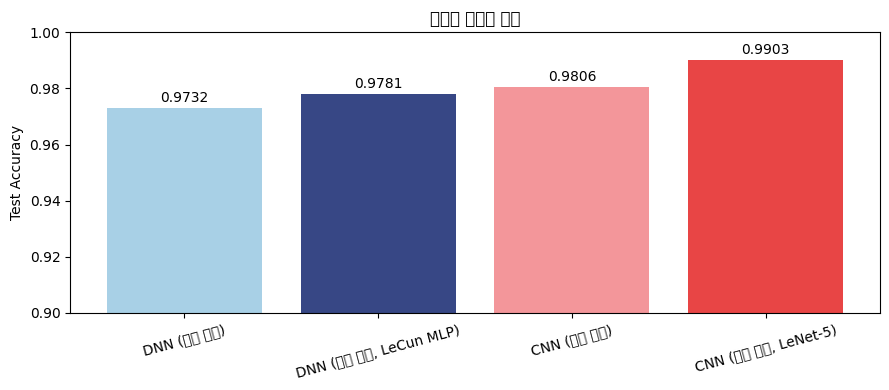

In [13]:
results = {
    "DNN (기초 실습)": (dnn_basic_acc, dnn_basic.count_params()),
    "DNN (논문 구조, LeCun MLP)": (dnn_paper_acc, dnn_paper.count_params()),
    "CNN (기초 실습)": (cnn_basic_acc, cnn_basic.count_params()),
    "CNN (논문 구조, LeNet-5)": (lenet5_acc, lenet5.count_params()),
}

print(f"{'모델':<26}{'테스트 정확도':<15}{'파라미터 수':<15}")
for name, (acc, params) in results.items():
    print(f"{name:<26}{acc:<15.4f}{params:<15,}")

names = list(results.keys())
accs = [v[0] for v in results.values()]

plt.figure(figsize=(9,4))
plt.bar(names, accs, color=['#a8d0e6','#374785','#f3969a','#e84545'])
plt.ylim(0.9, 1.0)
plt.ylabel('Test Accuracy')
plt.title('모델별 정확도 비교')
plt.xticks(rotation=15)
for i, v in enumerate(accs):
    plt.text(i, v+0.002, f"{v:.4f}", ha='center')
plt.tight_layout()
plt.show()


## 14. LeNet-5가 학습한 필터 시각화

CNN의 첫 번째 Conv층이 어떤 패턴을 스스로 학습했는지 눈으로 확인해봅니다.
사람이 정해준 필터가 아니라, 학습 과정에서 데이터로부터 스스로 만들어낸 필터라는 점이 포인트입니다.
이 셀은 그대로 실행하세요.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52395 (\N{HANGUL SYLLABLE CEOS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51704 (\N{HANGUL SYLLABLE JJAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52789 (\N{HANGUL SYLLABLE CEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

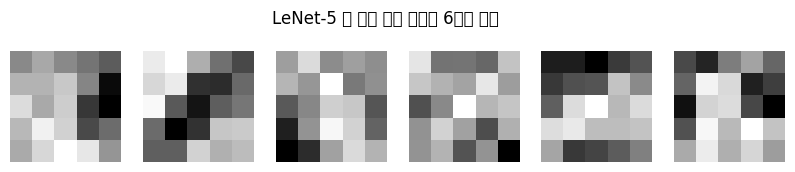

In [14]:
first_conv_weights = lenet5.layers[0].get_weights()[0]  # shape: (5,5,1,6)

fig, axes = plt.subplots(1, 6, figsize=(10,2))
for i, ax in enumerate(axes.flat):
    ax.imshow(first_conv_weights[:,:,0,i], cmap='gray')
    ax.axis('off')
plt.suptitle("LeNet-5 첫 번째 층이 학습한 6개의 필터")
plt.show()


## 15. 정리

**오늘 배운 것 정리**
- DNN은 이미지를 1차원으로 펼치면서 공간 정보를 잃는 반면, CNN은 합성곱 연산으로 공간 정보를 유지한 채 특징을 추출합니다.
- 기초 실습 구조에서 논문 구조로 갈수록 (은닉층/필터 수 증가) 일반적으로 성능이 향상되지만, 그만큼 파라미터 수와 학습 시간도 늘어납니다.


**함께 생각해볼 질문**
1. 은닉층/파라미터를 늘리면 (기초 실습 → 논문 구조) 정확도가 어떻게, 얼마나 바뀌었나요? DNN과 CNN에서 그 차이가 비슷한가요, 다른가요?
2. 파라미터 수가 늘어난다고 항상 성능이 좋아질까요? 그렇지 않다면 어떤 경우에 그럴까요? (힌트: 과적합)
3. 오늘 만든 구조들과 비교했을 때, 최근 CNN 구조(ResNet 등)는 어떤 점이 다를까요? (관심 있으면 직접 찾아보기)
